In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

# Allow importing the package from the repo root
sys.path.insert(0, str(Path(".").resolve().parent))

from qaoa_parameter_setting.utils.database.results_database import ResultsDatabase

import figure_styles

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [ ]:
# ── constants ────────────────────────────────────────────────────────────────
NUM_FILES  = 10           # expected distinct graph instances per (method, depth)
DATA_DIR   = "../data/training/random_regular"
OUTPUT_FILE = "figure_12.pdf"

SV_METHOD_LABELS = [
    "Fourier*",
    "Fourier refined*",
]

In [ ]:
# ── Load data via ResultsDatabase ────────────────────────────────────────────

warnings.simplefilter("ignore")

db = ResultsDatabase(problem_class="MC", num_nodes=[20])
db.add_data(DATA_DIR)

df = db.to_dataframe().pipe(lambda d: d[
    (d["evaluation_label"] == "SV")
    & d["instance"].str.contains("random3regular")
    & d["method_label"].isin(SV_METHOD_LABELS)
]).copy()
df["_src_depth"] = (
    df["source_file"]
    .str.extract(r'_(\d+)\.json$', expand=False)
    .astype(int)
)
df = (
    df
    .sort_values(
        ["_src_depth", "run_datetime", "energy"],
        ascending=[False, False, False],
    )
    .drop_duplicates(subset=["instance", "method_label", "depth"])
    .drop(columns=["_src_depth"])
)
    
print(f"Rows loaded — SV: {len(df)}")

Rows loaded — SV: 200


In [13]:
# ── Coverage report ──────────────────────────────────────────────────────────

stats = (
    df.groupby(["method_label", "depth"])["instance"]
    .count()
    .reset_index(name="n")
)
for _, row in stats.iterrows():
    flag = " *** BELOW TARGET ***" if row["n"] < NUM_FILES else ""
    print(
        f"  method={row['method_label']!r:20s}  depth={row['depth']:2d}  "
        f"n={row['n']}/{NUM_FILES}{flag}"
    )

  method='Fourier refined*'    depth= 1  n=10/10
  method='Fourier refined*'    depth= 2  n=10/10
  method='Fourier refined*'    depth= 3  n=10/10
  method='Fourier refined*'    depth= 4  n=10/10
  method='Fourier refined*'    depth= 5  n=10/10
  method='Fourier refined*'    depth= 6  n=10/10
  method='Fourier refined*'    depth= 7  n=10/10
  method='Fourier refined*'    depth= 8  n=10/10
  method='Fourier refined*'    depth= 9  n=10/10
  method='Fourier refined*'    depth=10  n=10/10
  method='Fourier*'            depth= 1  n=10/10
  method='Fourier*'            depth= 2  n=10/10
  method='Fourier*'            depth= 3  n=10/10
  method='Fourier*'            depth= 4  n=10/10
  method='Fourier*'            depth= 5  n=10/10
  method='Fourier*'            depth= 6  n=10/10
  method='Fourier*'            depth= 7  n=10/10
  method='Fourier*'            depth= 8  n=10/10
  method='Fourier*'            depth= 9  n=10/10
  method='Fourier*'            depth=10  n=10/10


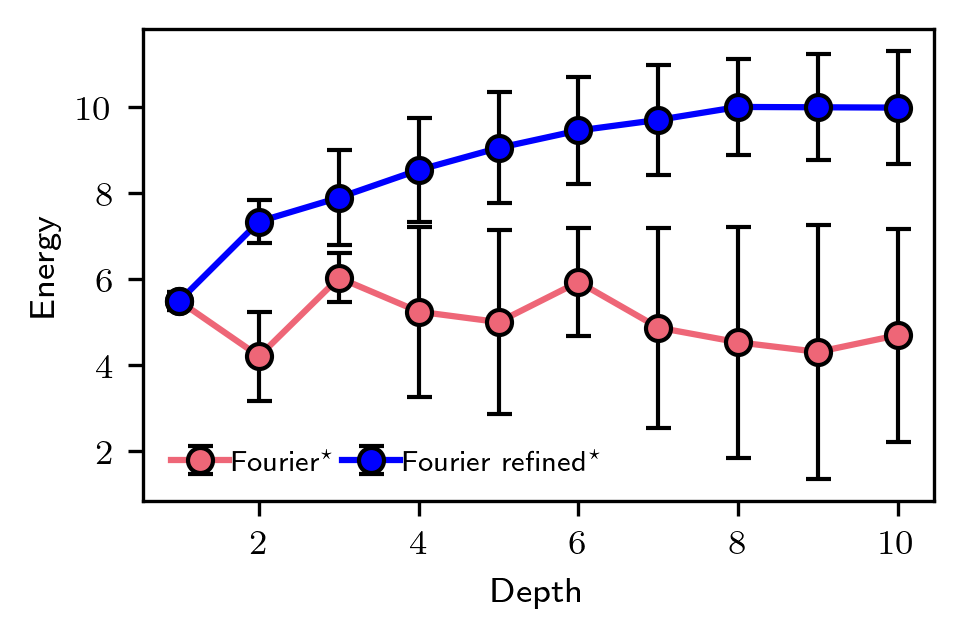

In [14]:
figure_styles.apply_rcparams()
layout = figure_styles.construct_plot(aspect_ratio=1.0 / 0.6)

for method_label in SV_METHOD_LABELS:
    rows = df[df["method_label"] == method_label]
    if rows.empty:
        continue
    stats = (
        rows.groupby("depth")["energy"]
        .agg(mean="mean", std="std")
        .reset_index()
        .sort_values("depth")
    )
    layout.ax.errorbar(
        stats["depth"].to_numpy(),
        stats["mean"].to_numpy(),
        yerr=stats["std"].to_numpy(),
        label=figure_styles.format_method_label(method_label),
        **figure_styles.style_errorbar(method_label, "SV"),
    )

layout.ax.set_xlabel("Depth")
layout.ax.set_ylabel("Energy")
layout.ax.legend(loc="lower left",
    bbox_to_anchor=(0.01, 0.01),
    **{k: v for k, v in layout.method_legend_kw.items() if k not in ("loc", "bbox_to_anchor")},)

layout.fig.savefig(OUTPUT_FILE, **figure_styles.savefig_kwargs())
layout.fig.show()